# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty.

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [115]:
%pip install --upgrade plotly

## Import Statements

In [116]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [117]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [118]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames?
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

**<h3>Median_Household_Income_2015**






In [119]:
#view the shape of the data, which shows there are 29,322 rows ans 3 columns
df_hh_income.shape

(29322, 3)

In [120]:
#view the data info
df_hh_income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29322 entries, 0 to 29321
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Geographic Area  29322 non-null  object
 1   City             29322 non-null  object
 2   Median Income    29271 non-null  object
dtypes: object(3)
memory usage: 687.4+ KB


In [121]:
#view the data statistics
df_hh_income.describe(include='all')

,Geographic Area,City,Median Income
count,29322,29322,29271
unique,51,24249,14592
top,PA,Franklin city,(X)
freq,1762,16,1113


In [122]:
#view the first five rows of data
df_hh_income.head()

,Geographic Area,City,Median Income
0,AL,Abanda CDP,11207
1,AL,Abbeville city,25615
2,AL,Adamsville city,42575
3,AL,Addison town,37083
4,AL,Akron town,21667


In [123]:
#view the last five rows of data
df_hh_income.tail()

,Geographic Area,City,Median Income
29317,WY,Woods Landing-Jelm CDP,NaN
29318,WY,Worland city,41523
29319,WY,Wright town,77114
29320,WY,Yoder town,37500
29321,WY,Y-O Ranch CDP,NaN


In [124]:
#view 30 random rows of the data, there is an "(X)" in row 25844 and a "-" in row 15699 in the Median Income column.
df_hh_income.sample(30)

,Geographic Area,City,Median Income
12498,MN,Caledonia city,44493
28929,WI,Rhinelander city,34355
6949,IL,Northfield village,96989
23167,PA,West Chester borough,47042
15911,NJ,Brigantine city,57031
16298,NJ,Singac CDP,71719
13274,MN,Worthington city,47467
22144,PA,Harleysville CDP,81228
17766,NY,St. Johnsville village,34679
10690,LA,Reserve CDP,49137


**<h3>PCT_People_Below_Poverty_Level**

In [125]:
#view the shape of the data, which shows there are 29,329 rows ans 3 columns
df_pct_poverty.shape

(29329, 3)

In [126]:
#view the data info
df_pct_poverty.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29329 entries, 0 to 29328
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Geographic Area  29329 non-null  object
 1   City             29329 non-null  object
 2   poverty_rate     29329 non-null  object
dtypes: object(3)
memory usage: 687.5+ KB


In [127]:
#view the data statistics
df_pct_poverty.describe(include='all')

,Geographic Area,City,poverty_rate
count,29329,29329,29329
unique,51,24255,771
top,PA,Franklin city,0
freq,1762,16,1464


In [128]:
#view the first five rows of data
df_pct_poverty.head()

,Geographic Area,City,poverty_rate
0,AL,Abanda CDP,78.8
1,AL,Abbeville city,29.1
2,AL,Adamsville city,25.5
3,AL,Addison town,30.7
4,AL,Akron town,42


In [129]:
#view the last five rows of data
df_pct_poverty.tail()

,Geographic Area,City,poverty_rate
29324,WY,Woods Landing-Jelm CDP,18.6
29325,WY,Worland city,15.3
29326,WY,Wright town,5.9
29327,WY,Yoder town,5.4
29328,WY,Y-O Ranch CDP,0


In [130]:
#view 30 random rows of the data, there is a '-' (missing value) in poverty_rate for some rows
df_pct_poverty.sample(30)

,Geographic Area,City,poverty_rate
2457,CA,Glendora city,9.4
235,AL,Haleyville city,26.8
13415,MS,Gulf Hills CDP,13.8
10609,LA,Metairie CDP,13.8
4625,FL,Matlacha CDP,11.4
17272,NY,Hall CDP,0
3125,CA,San Francisco city,13.2
20424,OK,Ashland town,5.1
6666,IL,Johnsburg village,6.9
9997,KY,Greensburg city,17.9


**<h3>PCT_Over_25_Completed_High_School**

In [131]:
#view the shape of the data, which shows there are 29,329 rows ans 3 columns
df_pct_completed_hs.shape

(29329, 3)

In [132]:
#view the data info
df_pct_completed_hs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29329 entries, 0 to 29328
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Geographic Area       29329 non-null  object
 1   City                  29329 non-null  object
 2   percent_completed_hs  29329 non-null  object
dtypes: object(3)
memory usage: 687.5+ KB


In [133]:
#view the data statistics
df_pct_completed_hs.describe(include='all')

,Geographic Area,City,percent_completed_hs
count,29329,29329,29329
unique,51,24255,728
top,PA,Franklin city,100
freq,1762,16,1301


In [134]:
#view the first five rows of data
df_pct_completed_hs.head()

,Geographic Area,City,percent_completed_hs
0,AL,Abanda CDP,21.2
1,AL,Abbeville city,69.1
2,AL,Adamsville city,78.9
3,AL,Addison town,81.4
4,AL,Akron town,68.6


In [135]:
#view the last five rows of data
df_pct_completed_hs.tail()

,Geographic Area,City,percent_completed_hs
29324,WY,Woods Landing-Jelm CDP,100
29325,WY,Worland city,85.6
29326,WY,Wright town,89.2
29327,WY,Yoder town,79.4
29328,WY,Y-O Ranch CDP,100


In [136]:
#view 50 random rows of the data, there is a '-' (missing value) in percent_completed_hs for row 24980
df_pct_completed_hs.sample(30)

,Geographic Area,City,percent_completed_hs
15318,NE,Inglewood village,89.3
7480,IN,Bristol town,87.2
1616,AR,Helena-West Helena city,77.1
4308,FL,Daytona Beach Shores city,95.3
13590,MS,Sledge town,71.7
7367,IL,Western Springs village,98.9
16809,NM,Tucumcari city,81.3
12994,MN,Oakdale city,94.3
26140,TX,Tuleta CDP,88.8
24906,TX,Delmita CDP,52.9


**<h3>Share_of_Race_By_City**

In [137]:
#view the shape of the data, which shows there are 29,268 rows ans 7 columns
df_share_race_city.shape

(29268, 7)

In [138]:
#view the data info
df_share_race_city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29268 entries, 0 to 29267
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Geographic area        29268 non-null  object
 1   City                   29268 non-null  object
 2   share_white            29268 non-null  object
 3   share_black            29268 non-null  object
 4   share_native_american  29268 non-null  object
 5   share_asian            29268 non-null  object
 6   share_hispanic         29268 non-null  object
dtypes: object(7)
memory usage: 1.6+ MB


In [139]:
#view the data statistics
df_share_race_city.describe()

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
count,29268,29268,29268,29268,29268,29268,29268
unique,51,24219,997,926,628,409,956
top,PA,Franklin city,100,0,0,0,0
freq,1764,16,1051,6587,6930,8537,2489


In [140]:
#view the first five rows of data
df_share_race_city.head()

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
0,AL,Abanda CDP,67.2,30.2,0,0,1.6
1,AL,Abbeville city,54.4,41.4,0.1,1,3.1
2,AL,Adamsville city,52.3,44.9,0.5,0.3,2.3
3,AL,Addison town,99.1,0.1,0,0.1,0.4
4,AL,Akron town,13.2,86.5,0,0,0.3


In [141]:
#view the last five rows of data
df_share_race_city.tail()

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
29263,WY,Woods Landing-Jelm CDP,95.9,0,0,2.1,0
29264,WY,Worland city,89.9,0.3,1.3,0.6,16.6
29265,WY,Wright town,94.5,0.1,1.4,0.2,6.2
29266,WY,Yoder town,97.4,0,0,0,4
29267,WY,Y-O Ranch CDP,92.8,1.5,2.6,0,11.8


In [142]:
#view 30 random rows of the data, there is '(X)' (missing values) for row 26108
df_share_race_city.sample(30)

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic
22552,PA,New Ringgold borough,96.4,1.4,0.7,0,1.8
8156,IA,Baldwin city,100,0,0,0,0
20211,OH,Timberlake village,96.3,0.6,0.6,0.6,2.4
26449,UT,Peter CDP,98.8,0.6,0,0.3,2.5
29131,WY,Fairview CDP,97.8,0,0,0,3.3
22690,PA,Plum borough,93.9,3.6,0.1,1.1,0.9
28570,WI,Green Bay city,77.9,3.5,4.1,4,13.4
16215,NJ,Point Pleasant Beach borough,92.3,0.8,0.2,0.8,9
28676,WI,Laona CDP,96.2,0.3,1.5,0,0.9
810,AK,Northway Junction CDP,22.2,0,66.7,0,1.9


**<h3>Deaths_By_Police**

In [143]:
#view the shape of the data, which shows there are 2,535 rows ans 14 columns
df_fatalities.shape

(2535, 14)

In [144]:
#view the data info
df_fatalities.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2535 entries, 0 to 2534
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       2535 non-null   int64  
 1   name                     2535 non-null   object 
 2   date                     2535 non-null   object 
 3   manner_of_death          2535 non-null   object 
 4   armed                    2526 non-null   object 
 5   age                      2458 non-null   float64
 6   gender                   2535 non-null   object 
 7   race                     2340 non-null   object 
 8   city                     2535 non-null   object 
 9   state                    2535 non-null   object 
 10  signs_of_mental_illness  2535 non-null   bool   
 11  threat_level             2535 non-null   object 
 12  flee                     2470 non-null   object 
 13  body_camera              2535 non-null   bool   
dtypes: bool(2), float64(1), 

In [145]:
#view the data statistics
df_fatalities.describe(include='all')

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
count,"2,535.00",2535,2535,2535,2526,"2,458.00",2535,2340,2535,2535,2535,2535,2470,2535
unique,NaN,2481,879,2,68,NaN,2,6,1417,51,2,3,4,2
top,NaN,TK TK,27/01/16,shot,gun,NaN,M,W,Los Angeles,CA,False,attack,Not fleeing,False
freq,NaN,49,8,2363,1398,NaN,2428,1201,39,424,1902,1611,1695,2264
mean,"1,445.73",NaN,NaN,NaN,NaN,36.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,794.26,NaN,NaN,NaN,NaN,13.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,3.00,NaN,NaN,NaN,NaN,6.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,768.50,NaN,NaN,NaN,NaN,26.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,"1,453.00",NaN,NaN,NaN,NaN,34.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,"2,126.50",NaN,NaN,NaN,NaN,45.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [146]:
#view the first five rows of data
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
0,3,Tim Elliot,02/01/15,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False
1,4,Lewis Lee Lembke,02/01/15,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False
2,5,John Paul Quintero,03/01/15,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False
3,8,Matthew Hoffman,04/01/15,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False
4,9,Michael Rodriguez,04/01/15,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False


In [147]:
#view the last five rows of data
df_fatalities.tail()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
2530,2822,Rodney E. Jacobs,28/07/17,shot,gun,31.00,M,NaN,Kansas City,MO,False,attack,Not fleeing,False
2531,2813,TK TK,28/07/17,shot,vehicle,NaN,M,NaN,Albuquerque,NM,False,attack,Car,False
2532,2818,Dennis W. Robinson,29/07/17,shot,gun,48.00,M,NaN,Melba,ID,False,attack,Car,False
2533,2817,Isaiah Tucker,31/07/17,shot,vehicle,28.00,M,B,Oshkosh,WI,False,attack,Car,True
2534,2815,Dwayne Jeune,31/07/17,shot,knife,32.00,M,B,Brooklyn,NY,True,attack,Not fleeing,False


In [148]:
#view 30 random rows of the data
df_fatalities.sample(30)

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera
116,157,Michael K. Casper,16/02/15,shot,gun,26.00,M,W,Boise,ID,False,attack,Not fleeing,False
203,225,Kaylene Stone,18/03/15,shot,gun,49.00,F,W,Glendale,AZ,False,attack,Not fleeing,False
1254,1430,Melissa Boarts,03/04/16,shot,unknown weapon,36.00,F,W,Macon County,AL,True,other,Not fleeing,True
975,1127,Omar Ventura,24/12/15,shot,knife,23.00,M,H,Porterville,CA,False,other,Not fleeing,False
1481,1671,Walden Dang,28/06/16,shot,knife,61.00,M,A,Honolulu,HI,False,attack,Not fleeing,False
929,1075,Steven Wickert,11/12/15,shot,unarmed,36.00,M,W,Tucson,AZ,False,attack,Not fleeing,False
2172,2421,Rashad Daquan Opher,13/03/17,shot,vehicle,20.00,M,B,Woodlawn,MD,False,other,Other,True
1397,1584,TK TK,01/06/16,shot,gun,NaN,M,NaN,Phoenix,AZ,False,attack,Not fleeing,False
2298,2557,Jacob Peterson,06/05/17,shot,toy weapon,15.00,M,W,San Diego,CA,True,attack,Not fleeing,True
1739,1947,Dylan Rogers,08/10/16,shot,vehicle,39.00,M,NaN,Wetumka,OK,False,other,Not fleeing,False


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate.

**<h3>Median_Household_Income_2015**

In [149]:
#check for missing values
df_hh_income.isna().values.any()

np.True_

In [150]:
#it was discovered that there are '(X)' and '-' present (missing data) in the Median Income column, but they are seen as strings and will not be detected by isna()

#Create a flag column to track which rows had zero and '-' values originally
df_hh_income['income_missing'] = df_hh_income['Median Income'].isin([0, '-'])

In [151]:
#Replace dash strings with NAN
df_hh_income['Median Income'] = df_hh_income['Median Income'].replace("-", np.nan)

#Replace '(X)' values with NAN
df_hh_income['Median Income'] = df_hh_income['Median Income'].replace("(X)", np.nan)

In [152]:
#check to see how many values are missing
df_hh_income.isna().values.sum()

np.int64(1904)

In [153]:
#check to see how many mising values are in each column
df_hh_income.isna().sum()

,0
Geographic Area,0
City,0
Median Income,1904
income_missing,0


In [154]:
#check for duplicates
df_hh_income.duplicated().any()

np.False_

In [155]:
#fill missing income values with the median income value instead of zero

#convert 'Median Income' column to numeric
df_hh_income['Median Income'] = pd.to_numeric(df_hh_income['Median Income'], errors='coerce')

#calcuate the median income
median_income = df_hh_income['Median Income'].median()
print(f'The median income is: ${median_income: .0f}')

#fill missing values with the median
df_hh_income['Median Income'] = df_hh_income['Median Income'].fillna(median_income)


The median income is: $ 45305


In [156]:
#recheck for missing values
df_hh_income.isna().values.any()

np.False_

In [157]:
#view the last five rows to confirm NaN have been replaced with the median income
df_hh_income.tail()

,Geographic Area,City,Median Income,income_missing
29317,WY,Woods Landing-Jelm CDP,"45,305.00",False
29318,WY,Worland city,"41,523.00",False
29319,WY,Wright town,"77,114.00",False
29320,WY,Yoder town,"37,500.00",False
29321,WY,Y-O Ranch CDP,"45,305.00",False


In [158]:
#confirm that missing values '(X)' and '-' were replaced
income_filled = df_hh_income[df_hh_income['income_missing']==True]
income_filled

,Geographic Area,City,Median Income,income_missing
71,AL,Bucks CDP,"45,305.00",True
74,AL,Calvert CDP,"45,305.00",True
84,AL,Catherine CDP,"45,305.00",True
338,AL,Megargel CDP,"45,305.00",True
462,AL,Rockville CDP,"45,305.00",True
...,...,...,...,...
28258,WV,Roderfield CDP,"45,305.00",True
28299,WV,Tioga CDP,"45,305.00",True
28311,WV,Vivian CDP,"45,305.00",True
28332,WV,Whitmer CDP,"45,305.00",True


In [159]:
#view new statistics
df_hh_income.describe(include='all')

,Geographic Area,City,Median Income,income_missing
count,29322,29322,"29,322.00",29322
unique,51,24249,NaN,2
top,PA,Franklin city,NaN,False
freq,1762,16,NaN,28582
mean,NaN,NaN,"50,789.93",NaN
std,NaN,NaN,"24,095.43",NaN
min,NaN,NaN,"4,511.00",NaN
25%,NaN,NaN,"36,250.00",NaN
50%,NaN,NaN,"45,305.00",NaN
75%,NaN,NaN,"57,857.00",NaN


**<h3>PCT_People_Below_Poverty_Level**

In [160]:
#check for missing values, #It was discovered that there are '-' present (missing data) in the poverty_rate column,
#but they are seen as strings and will not be detected by isna()
df_pct_poverty.isna().values.any()

np.False_

In [161]:
#Create a flag column to track which rows had '-' values originally
df_pct_poverty['pov_rate_missing'] = df_pct_poverty['poverty_rate'].isin(['-'])

In [162]:
#Replace dash strings with NAN
df_pct_poverty['poverty_rate'] = df_pct_poverty['poverty_rate'].replace("-", np.nan)

In [163]:
#check to see how many values are missing
df_pct_poverty.isna().values.sum()

np.int64(201)

In [164]:
#check for duplicates
df_pct_poverty.duplicated().any()

np.False_

In [165]:
#change poverty_rate column to numerical
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')

#Fill missing rates using group-wise median by state
df_pct_poverty['poverty_rate'] = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].transform(lambda x: x.fillna(x.median()))

In [166]:
#recheck for missing values
df_pct_poverty.isna().values.any()

np.False_

In [167]:
#confirm that '-' missing values were replaced
pov_rate_filled_in = df_pct_poverty[df_pct_poverty['pov_rate_missing']==True]
pov_rate_filled_in

,Geographic Area,City,poverty_rate,pov_rate_missing
573,AL,Whatley CDP,19.10,True
608,AK,Attu Station CDP,14.95,True
632,AK,Chicken CDP,14.95,True
637,AK,Chisana CDP,14.95,True
662,AK,Dot Lake CDP,14.95,True
...,...,...,...,...
29261,WY,Oakley CDP,6.40,True
29266,WY,Owl Creek CDP,6.40,True
29273,WY,Powder River CDP,6.40,True
29289,WY,Ryan Park CDP,6.40,True


**<h3>PCT_Over_25_Completed_High_School**

In [168]:
#check for missing values, it was discovered that there are '-' present (missing data) in the percent_completed_hs column,
#but they are seen as strings and will not be detected by isna()
df_pct_completed_hs.isna().values.any()

np.False_

In [169]:
#Create a flag column to track which rows had zero and '-' values originally
df_pct_completed_hs['hs_pct_missing'] = df_pct_completed_hs['percent_completed_hs'].isin([0, '-'])

In [170]:
#Replace dash strings with NAN
df_pct_completed_hs['percent_completed_hs'] = df_pct_completed_hs['percent_completed_hs'].replace("-", np.nan)

#There are some zero values present, replace zero values with NAN
df_pct_completed_hs['percent_completed_hs'] = df_pct_completed_hs['percent_completed_hs'].replace(0, np.nan)

In [171]:
#recheck for missing values
df_pct_completed_hs.isna().values.any()

np.True_

In [172]:
#check to see how many values are missing
df_pct_completed_hs.isna().values.sum()

np.int64(197)

In [173]:
#check for duplicates
df_pct_completed_hs.duplicated().any()

np.False_

In [174]:
#change percent_complete_hs column to numerical
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'], errors='coerce')

#Fill missing percents using group-wise median by state
df_pct_completed_hs['percent_completed_hs'] = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].transform(lambda x: x.fillna(x.median()))

In [175]:
#recheck for missing values
df_pct_completed_hs.isna().values.any()

np.False_

In [176]:
#confirm that '-' missing values were replaced
hs_pct_filled_in = df_pct_completed_hs[df_pct_completed_hs['hs_pct_missing']==True]
hs_pct_filled_in

,Geographic Area,City,percent_completed_hs,hs_pct_missing
573,AL,Whatley CDP,81.15,True
632,AK,Chicken CDP,87.60,True
637,AK,Chisana CDP,87.60,True
662,AK,Dot Lake CDP,87.60,True
667,AK,Edna Bay city,87.60,True
...,...,...,...,...
29261,WY,Oakley CDP,93.70,True
29266,WY,Owl Creek CDP,93.70,True
29273,WY,Powder River CDP,93.70,True
29289,WY,Ryan Park CDP,93.70,True


**<h3>Share_of_Race_By_City**

In [177]:
#check for missing values, #It was discovered that there are '(X)' present (missing data) all race columns,
#but they are seen as strings and will not be detected by isna()
df_share_race_city.isna().values.any()

np.False_

In [178]:
#Create a flag column to track which rows had '(X)' values originally
race_cols = [
    "share_white",
    "share_black",
    "share_native_american",
    "share_asian",
    "share_hispanic"
]

# Create a flag column that checks if any race column has '(X)'
df_share_race_city["race_missing"] = df_share_race_city[race_cols].apply(
    lambda row: "(X)" in row.values, axis=1
)

In [179]:
#replace '(X)' with NaN
df_share_race_city[race_cols] = df_share_race_city[race_cols].replace("(X)", np.nan)

In [180]:
#recheck for missing values
df_share_race_city.isna().values.any()

np.True_

In [181]:
#check to see how many values are missing
df_share_race_city.isna().values.sum()

np.int64(100)

In [182]:
#check for duplicates
df_share_race_city.duplicated().any()

np.False_

In [183]:
#change share of race columns to numerical
df_share_race_city["share_white"] = pd.to_numeric(df_share_race_city["share_white"], errors='coerce')
df_share_race_city["share_black"] = pd.to_numeric(df_share_race_city["share_black"], errors='coerce')
df_share_race_city["share_native_american"] = pd.to_numeric(df_share_race_city["share_native_american"], errors='coerce')
df_share_race_city["share_asian"] = pd.to_numeric(df_share_race_city["share_asian"], errors='coerce')
df_share_race_city["share_hispanic"] = pd.to_numeric(df_share_race_city["share_hispanic"], errors='coerce')

In [184]:
#Fill missing race data using group-wise median by state
df_share_race_city[race_cols] = df_share_race_city.groupby("Geographic area")[race_cols].transform(lambda group: group.fillna(group.median()))

In [185]:
#recheck for missing values
df_share_race_city.isna().values.any()

np.False_

In [186]:
#confirm that '(X)' missing values were replaced
race_filled_in = df_share_race_city[df_share_race_city['race_missing']==True]
race_filled_in

,Geographic area,City,share_white,share_black,share_native_american,share_asian,share_hispanic,race_missing
630,AK,Chisana CDP,39.90,0.00,38.90,0.00,1.20,True
678,AK,Flat CDP,39.90,0.00,38.90,0.00,1.20,True
777,AK,Mertarvik CDP,39.90,0.00,38.90,0.00,1.20,True
1946,CA,Almanor CDP,77.30,0.90,1.10,2.00,19.30,True
2134,CA,Caribou CDP,77.30,0.90,1.10,2.00,19.30,True
2160,CA,Cedar Slope CDP,77.30,0.90,1.10,2.00,19.30,True
3194,CA,Silver City CDP,77.30,0.90,1.10,2.00,19.30,True
3248,CA,Sugarloaf Mountain Park CDP,77.30,0.90,1.10,2.00,19.30,True
3331,CA,University of California Merced CDP,77.30,0.90,1.10,2.00,19.30,True
3345,CA,Valley Wells CDP,77.30,0.90,1.10,2.00,19.30,True


**<h3>Deaths_By_Police**

In [187]:
#check for missing values
df_fatalities.isna().values.any()

np.True_

In [188]:
#check to see how many values are missing
df_fatalities.isna().values.sum()

np.int64(346)

In [189]:
#check to see how many mising values are in each column
df_fatalities.isna().sum()

,0
id,0
name,0
date,0
manner_of_death,0
armed,9
age,77
gender,0
race,195
city,0
state,0


In [190]:
#check for duplicates
df_fatalities.duplicated().any()

np.False_

In [191]:
#fill missing values with "Unknown"
df_fatalities['armed'] = df_fatalities['armed'].fillna('Unknown')

df_fatalities['race'] = df_fatalities['race'].fillna('UNK')

df_fatalities['flee'] = df_fatalities['flee'].fillna('Unknown')

In [192]:
#Find the percent of ages missing
pct_age_missing = df_fatalities['age'].isna().mean()
print(f"The percent of ages missing is {int(pct_age_missing * 100)}%")

# Calculate percent of missing age values by race
missing_by_race = df_fatalities['age'].isna().groupby(df_fatalities['race']).mean()

# Display as percentages
print((missing_by_race * 100).round(2))


The percent of ages missing is 3%
race
A      2.56
B      1.46
H      2.36
N      0.00
O      0.00
UNK   24.62
W      0.75
Name: age, dtype: float64


In [193]:
#Create a flag for missing age
df_fatalities['age_missing'] = df_fatalities['age'].isna()

In [194]:
#Fill missing age using group-wise median by race
df_fatalities['age'] = df_fatalities.groupby('race')['age'].transform(lambda x: x.fillna(x.median()))

In [195]:
#Fill UNK races ages separately with overall median
median_age = df_fatalities['age'].median()
df_fatalities.loc[df_fatalities['race'] == 'UNK', 'age'] = \
    df_fatalities.loc[df_fatalities['race'] == 'UNK', 'age'].fillna(median_age)

In [196]:
#recheck for missing values
df_fatalities.isna().values.any()

np.False_

In [197]:
#confirm that missing age has been replaced
age_filled = df_fatalities[df_fatalities['age_missing']==True]
age_filled

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,age_missing
124,584,Alejandro Salazar,20/02/15,shot,gun,31.00,M,H,Houston,TX,False,attack,Car,False,True
658,789,Roger Albrecht,29/08/15,shot,knife,38.00,M,W,San Antonio,TX,False,other,Not fleeing,False,True
707,839,Lawrence Price,17/09/15,shot,gun,38.00,M,W,Brodhead,KY,False,attack,Not fleeing,False,True
769,908,Jason Day,12/10/15,shot,gun,30.00,M,B,Lawton,OK,False,attack,Not fleeing,False,True
802,1283,John Tozzi,24/10/15,shot,gun,39.00,M,UNK,New Paltz,NY,False,attack,Not fleeing,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2488,2773,TK TK,12/07/17,shot,blunt object,39.00,M,UNK,Grover Beach,CA,False,other,Not fleeing,False,True
2496,2781,TK TK,15/07/17,shot,gun,39.00,M,UNK,Arlington,TX,False,attack,Foot,False,True
2521,2806,TK TK,26/07/17,shot,gun,39.00,M,UNK,San Antonio,TX,False,attack,Not fleeing,False,True
2528,2812,Alejandro Alvarado,27/07/17,shot,knife,31.00,M,H,Chowchilla,CA,False,attack,Not fleeing,False,True


In [198]:
#view 30 random rows to confirm that all other missing values have been replaced with 'UKN' for race and 'Unknown' for armed and flee
df_fatalities.sample(50)

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,age_missing
2150,2398,Rafael Navarro-Garcia,02/03/17,shot,undetermined,25.00,M,H,Reno,NV,False,undetermined,Unknown,False,False
150,190,Cornelius J. Parker,28/02/15,shot,gun,28.00,M,B,Columbia,MO,False,attack,Car,False,False
1648,1850,Randall Rodick,02/09/16,shot,gun,40.00,M,UNK,Parker,CO,True,attack,Car,True,False
860,1003,Richard Perkins,15/11/15,shot,toy weapon,39.00,M,B,Oakland,CA,False,attack,Not fleeing,False,False
1186,1357,Peter Gaines,12/03/16,shot and Tasered,unarmed,37.00,M,B,Houston,TX,False,other,Foot,False,False
462,577,Alan Bellew,28/06/15,shot,toy weapon,29.00,M,W,Portland,OR,False,attack,Not fleeing,False,False
274,355,Mack Long,12/04/15,shot,gun,36.00,M,B,Indianapolis,IN,False,attack,Foot,True,False
2038,2274,Mi'Chance Dunlap-Gittens,28/01/17,shot,gun,17.00,M,B,Des Moines,WA,False,attack,Not fleeing,False,False
2052,2285,Yia Lee,03/02/17,shot,gun,41.00,M,A,Panhandle,TX,False,attack,Not fleeing,False,False
157,197,Fednel Rhinvil,03/03/15,shot,gun,25.00,M,B,Salisbury,MD,False,attack,Not fleeing,False,False


# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [199]:
#change poverty_rate column to numerical
df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')

#group mean poverty rate by state and order in descending order
state_poverty_rate = df_pct_poverty.groupby('Geographic Area', as_index=False).agg({'poverty_rate': pd.Series.mean}).sort_values('poverty_rate', ascending=False)
state_poverty_rate

,Geographic Area,poverty_rate
25,MS,26.88
3,AZ,25.58
10,GA,23.78
32,NM,23.00
2,AR,22.96
18,LA,22.34
40,SC,22.16
49,WV,21.13
36,OK,20.65
1,AL,20.64


In [200]:
#plot bar graph
pov_bar_graph = px.bar(y=state_poverty_rate['poverty_rate'],
                   x=state_poverty_rate['Geographic Area'],
                   title='Poverty Rate by State',
                   height=600)

pov_bar_graph.update_layout(yaxis_title='Mean Poverty Rate', xaxis_title='State',  xaxis_tickangle=45)

pov_bar_graph.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [201]:
#group mean percent by state in ascending order
hs_grad_by_state = df_pct_completed_hs.groupby('Geographic Area', as_index=False).agg({'percent_completed_hs': pd.Series.mean}).sort_values('percent_completed_hs', ascending=True)
hs_grad_by_state

,Geographic Area,percent_completed_hs
43,TX,75.79
25,MS,78.47
10,GA,79.01
18,LA,79.29
2,AR,79.95
1,AL,80.30
3,AZ,80.52
40,SC,80.85
32,NM,81.07
42,TN,81.63


In [202]:
#plot bar chart

hs_bar_graph = px.bar(x=hs_grad_by_state['Geographic Area'],
                      y=hs_grad_by_state['percent_completed_hs'],
                      title='High School Graduation Rate by State',
                      color=hs_grad_by_state['percent_completed_hs'],
                      color_continuous_scale='Viridis')

hs_bar_graph.update_layout(xaxis_title='State', yaxis_title='HS Graduation Rate', xaxis_tickangle=45)

hs_bar_graph.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

/tmp/ipython-input-1436921992.py:24: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



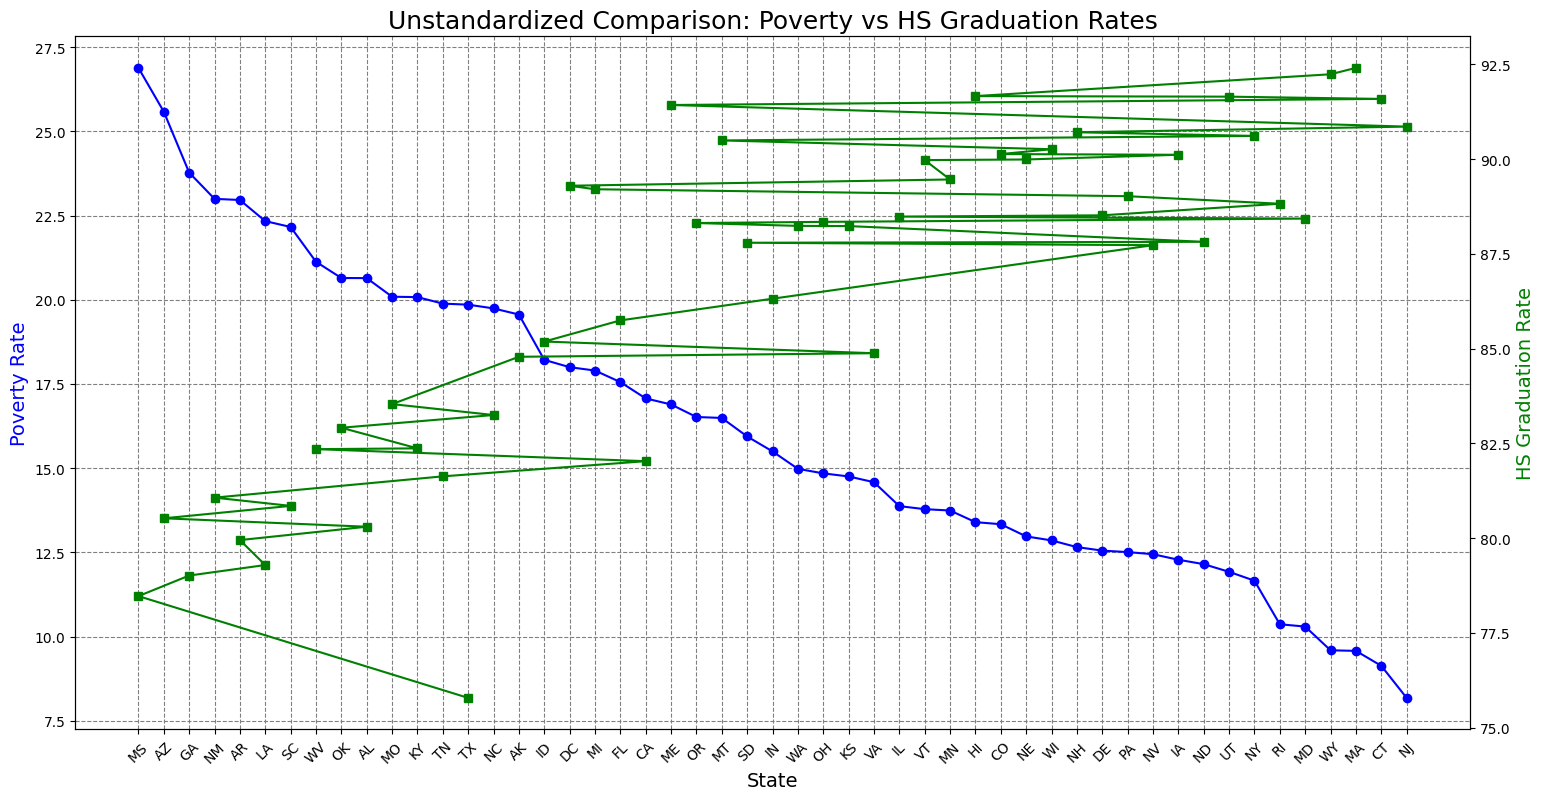

In [203]:
#set figure size and layout
plt.figure(figsize=(18,9))
plt.tight_layout()

#add grid
plt.grid(axis='both', color='grey', linestyle='--')

#get the axis
ax1 = plt.gca()

#create another axis that shares the same x-axis
ax2 = ax1.twinx()

#plot povery rates
ax1.plot(state_poverty_rate['Geographic Area'], state_poverty_rate['poverty_rate'], color='b', marker='o')
ax1.set_xlabel('State', fontsize=14)
ax1.set_ylabel('Poverty Rate', color='b', fontsize=14)

#plot hs graduation rates
ax2.plot(hs_grad_by_state['Geographic Area'], hs_grad_by_state['percent_completed_hs'], color='g', marker='s')
ax2.set_ylabel('HS Graduation Rate', color='g', fontsize=14)

plt.title('Unstandardized Comparison: Poverty vs HS Graduation Rates', fontsize=18)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

plt.show()

/tmp/ipython-input-2398533270.py:28: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



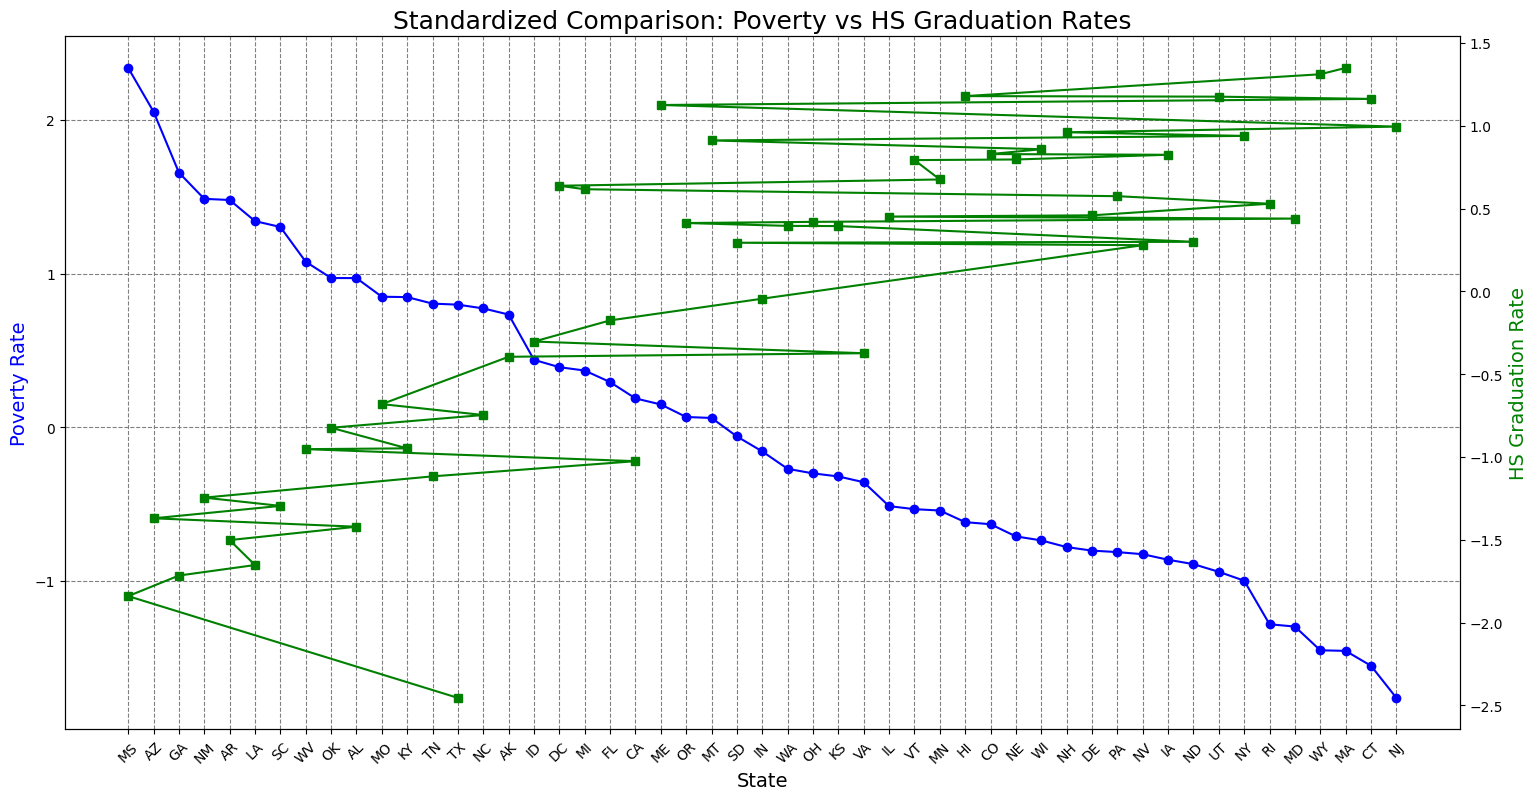

In [204]:
#standardize the data z_scores for poverty rate and hs graduation rate
state_poverty_rate['poverty_z'] = (state_poverty_rate['poverty_rate'] - state_poverty_rate['poverty_rate'].mean()) / state_poverty_rate['poverty_rate'].std()
hs_grad_by_state['hs_z'] = (hs_grad_by_state['percent_completed_hs'] - hs_grad_by_state['percent_completed_hs'].mean()) / hs_grad_by_state['percent_completed_hs'].std()

#set figure size and layout
plt.figure(figsize=(18,9))
plt.tight_layout()

#add grid
plt.grid(axis='both', color='grey', linestyle='--')

#get the axis
ax1 = plt.gca()

#create another axis that shares the same x-axis
ax2 = ax1.twinx()

#plot povery rates
ax1.plot(state_poverty_rate['Geographic Area'], state_poverty_rate['poverty_z'], color='b', marker='o')
ax1.set_xlabel('State', fontsize=14)
ax1.set_ylabel('Poverty Rate', color='b', fontsize=14)

#plot hs graduation rates
ax2.plot(hs_grad_by_state['Geographic Area'], hs_grad_by_state['hs_z'], color='g', marker='s')
ax2.set_ylabel('HS Graduation Rate', color='g', fontsize=14)

plt.title('Standardized Comparison: Poverty vs HS Graduation Rates', fontsize=18)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

In [205]:
#merge data frames
merged_df = pd.merge(
    state_poverty_rate[['Geographic Area', 'poverty_rate']],
    hs_grad_by_state[['Geographic Area', 'percent_completed_hs']],
    on='Geographic Area')
merged_df

,Geographic Area,poverty_rate,percent_completed_hs
0,MS,26.88,78.47
1,AZ,25.58,80.52
2,GA,23.78,79.01
3,NM,23.00,81.07
4,AR,22.96,79.95
5,LA,22.34,79.29
6,SC,22.16,80.85
7,WV,21.13,82.35
8,OK,20.65,82.91
9,AL,20.64,80.30


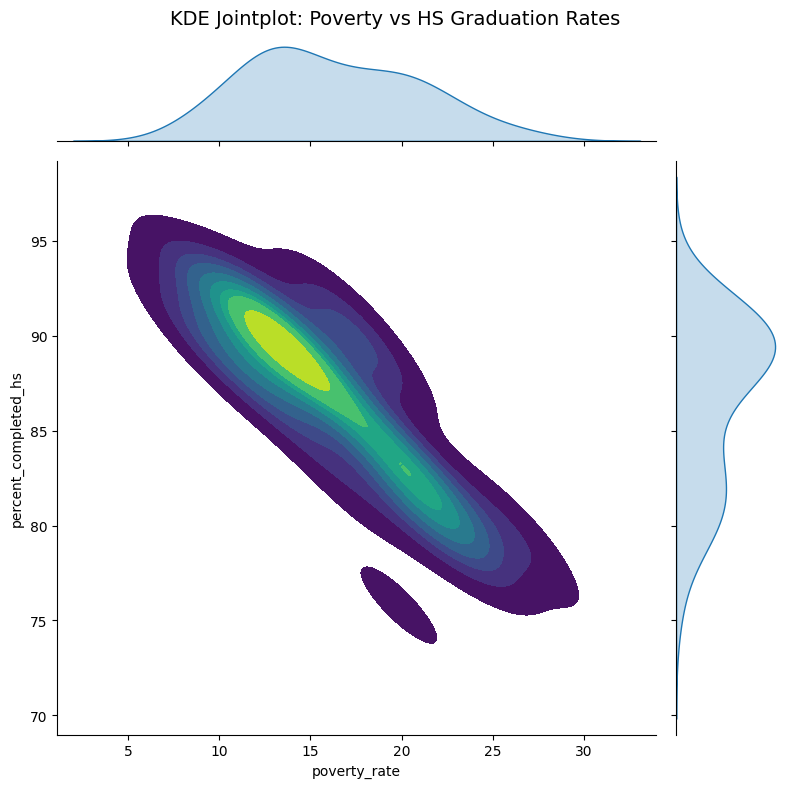

In [206]:
#create a Seaborn KDE Jointplot
sns.jointplot(data=merged_df, x='poverty_rate', y='percent_completed_hs', kind='kde', fill=True, cmap='viridis', height=8)
plt.suptitle('KDE Jointplot: Poverty vs HS Graduation Rates', fontsize=14)
plt.tight_layout()

plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio.

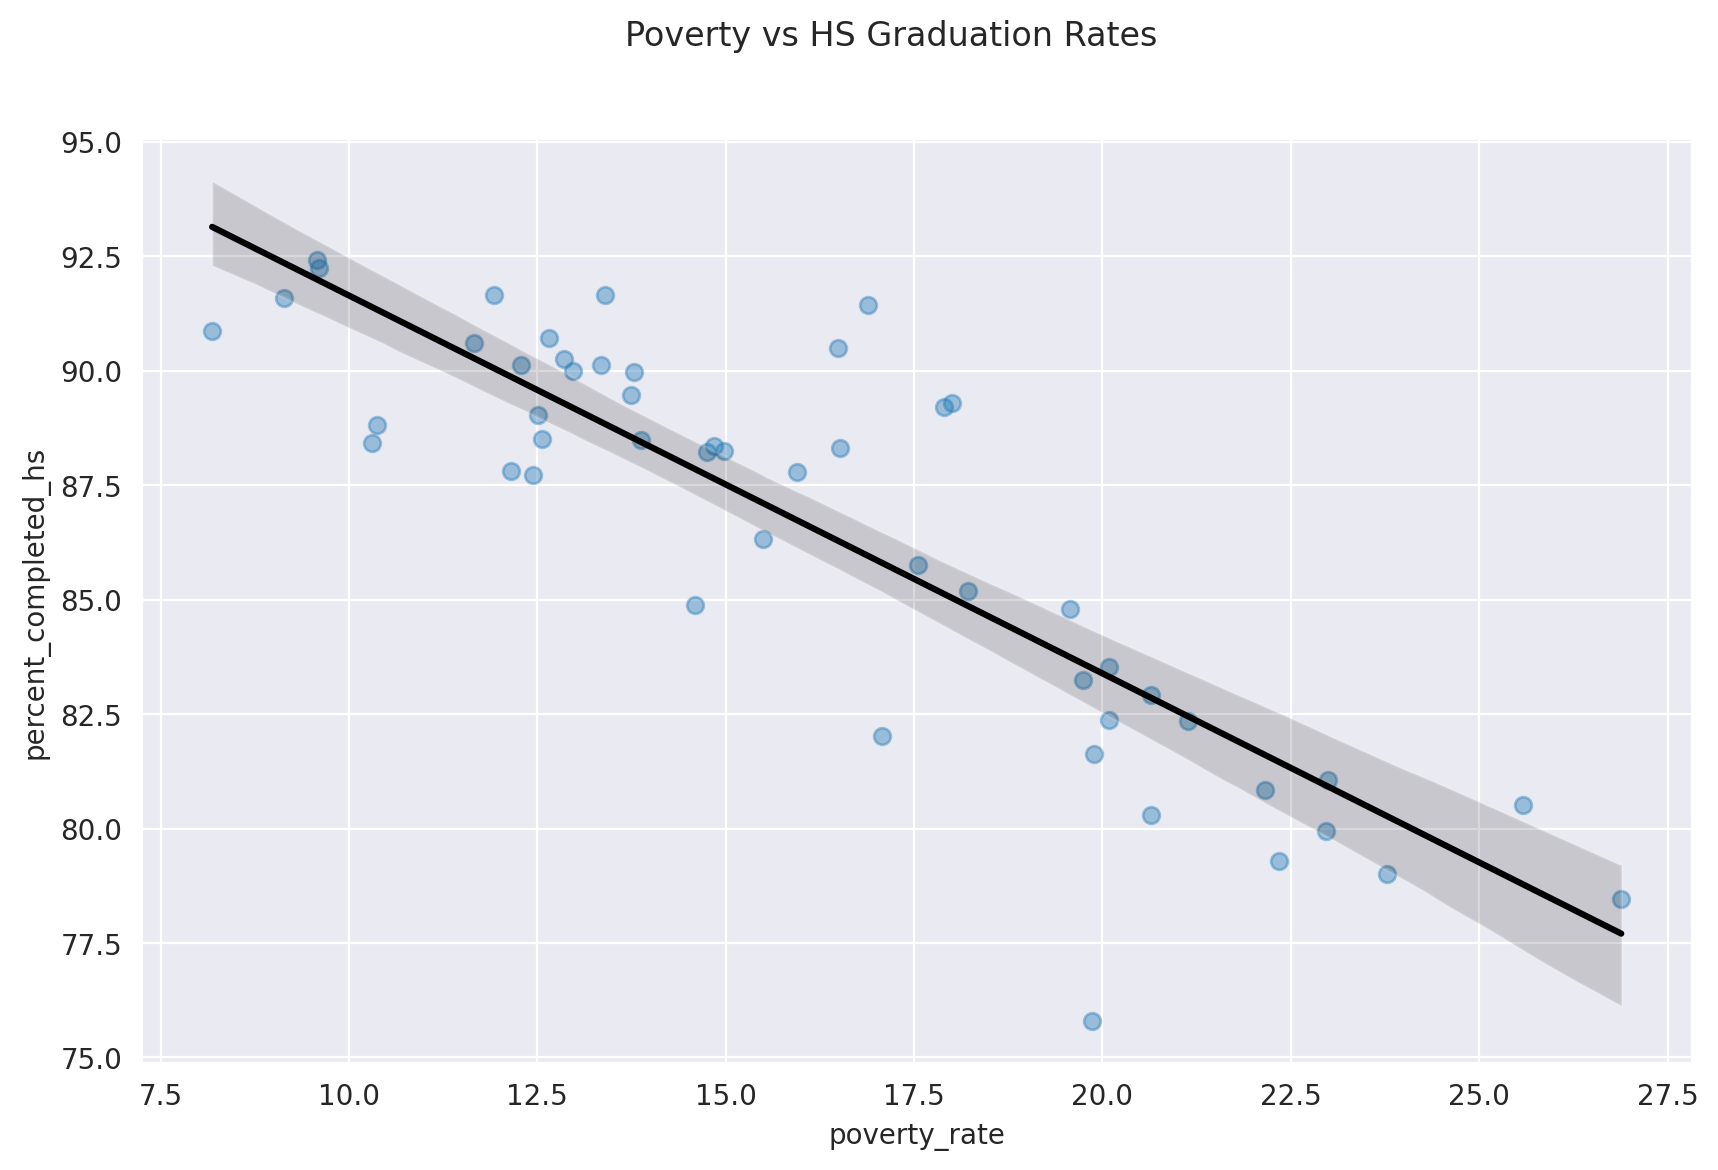

In [207]:
#create regression plot
plt.figure(figsize=(10,6), dpi=200)
with sns.axes_style('darkgrid'):
  sns.regplot(data=merged_df, x='poverty_rate', y='percent_completed_hs', scatter_kws={'alpha': 0.4}, line_kws = {'color': 'black'})
  plt.suptitle('Poverty vs HS Graduation Rates', fontsize=12)
  plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections.

In [208]:
#create a bar chart with subsections

#Group and normalize racial shares by state
grouped = df_share_race_city.groupby('Geographic area')[['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']].mean()

#Normalize to 100% per state
grouped_normalized = grouped.div(grouped.sum(axis=1), axis=0) * 100
grouped_normalized.reset_index(inplace=True)

#Melt for Plotly-This reshapes the data from wide format (one row per state, one column per race) to long format (one row per state–race combination).
melted = grouped_normalized.melt(id_vars='Geographic area', var_name='Race', value_name='Share')

#Plot graph
stack_bar = px.bar(
    melted,
    x='Geographic area',
    y='Share',
    color='Race',
    title='Normalized Racial Makeup by US State (100% Stacked)',
    labels={'Share': 'Population Share (%)'},
    height=600
)

stack_bar.update_layout(xaxis_tickangle=45, yaxis_range=[0, 100], bargap=0.3)

stack_bar.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [209]:
#get counts of people killed by race
race_killed = df_fatalities['race'].value_counts()
race_killed

,count
race,
W,1201
B,618
H,423
UNK,195
A,39
N,31
O,28


In [210]:
#plot donut chart
donut = px.pie(labels=race_killed.index,
               values=race_killed.values,
               title='Percentage of People Killed by Race',
               names=race_killed.index,
               hole=0.5)
donut.update_traces(textposition='inside', textfont_size=15, textinfo='percent', showlegend=True)

donut.show()


# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women.

In [211]:
#get the number killed by gender
gender_killed = df_fatalities['gender'].value_counts()
gender_killed

,count
gender,
M,2428
F,107


In [212]:
#plot pie chart
pie = px.pie(labels=gender_killed.index,
               values=gender_killed.values,
               title='Percentage of People Killed by Gender',
               names=gender_killed.index)

pie.update_traces(textposition='inside', textfont_size=15, textinfo='percent', showlegend=True)

pie.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death?

In [213]:
#create dataframe including only age, gender and manner of death
manner_of_death = df_fatalities[['age', 'gender','manner_of_death']]
manner_of_death.head()

,age,gender,manner_of_death
0,53.00,M,shot
1,47.00,M,shot
2,23.00,M,shot and Tasered
3,32.00,M,shot
4,39.00,M,shot


In [214]:
#plot boxplot
box_plot = px.box(manner_of_death,
                  x='manner_of_death',
                  y='age',
                  title='Manner of Death by Police by Age and Gender',
                  color='gender')

box_plot.update_layout(xaxis_title='Manner of Death', yaxis_title='Age at Time of Death')

box_plot.show()

# Were People Armed?

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed?

In [215]:
#Treat unarmed, undetermined, and unknown as not armed
not_armed_vals = ['unarmed', 'undetermined', 'unknown']

#filter data to contain only armed rows of data
armed = ~df_fatalities['armed'].isin(not_armed_vals)

#calculate the total sum of armed people
num_armed = armed.sum()

#calculate the total number of people
total = len(df_fatalities)

#calculate the percent of armed and unarmed people
percent_armed = (num_armed / total) * 100
percent_unarmed = 100 - percent_armed

print(f"Percent armed: {percent_armed:.1f}%")
print(f"Percent unarmed, undetermined or unknown: {percent_unarmed:.1f}%")

Percent armed: 88.6%
Percent unarmed, undetermined or unknown: 11.4%


In [216]:
#plot pie chart of percentage of armed people

#create dictionary for data to be ploted
data = {
    'status': ['Armed', 'Unarmed/Undetermined/Unknown'],
    'percent': [percent_armed, percent_unarmed]
}

#create dataframe
df_pie = pd.DataFrame(data)

pie = px.pie(df_pie,
             names='status',
             values='percent',
             title='Percentage of Police Killings: Armed vs Unarmed')

pie.show()

In [217]:
#Treat any type of gun as "armed with gun"
armed_gun_like = df_fatalities['armed'].str.contains('gun', case=False)
num_armed_gun_like = armed_gun_like.sum()
print(f"Number armed with any kind of gun: {num_armed_gun_like}")

#Treat unarmed, undetermined, and unknown as not armed
not_armed_vals = ['unarmed', 'undetermined', 'unknown']
unarmed =  df_fatalities['armed'].isin(not_armed_vals)
num_unarmed = unarmed.sum()
print(f"Number unarmed: {num_unarmed}")

Number armed with any kind of gun: 1411
Number unarmed: 288


In [218]:
#get count of armed vs unarmed
is_armed = df_fatalities['armed'].value_counts().reset_index()
is_armed

,armed,count
0,gun,1398
1,knife,373
2,vehicle,177
3,unarmed,171
4,undetermined,117
...,...,...
64,air conditioner,1
65,pole and knife,1
66,baseball bat and bottle,1
67,fireworks,1


In [219]:
#plot the top ten weapons people were armed with
bar = px.bar(is_armed[:10],
             x='armed',
             y='count',
             title='The Amount of People Police Killed: Top Ten Armed Categories')

bar.update_layout(xaxis_title='Weapon Type', yaxis_title='Count')

bar.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [220]:
#filter data to contain only people less than age 25 and get the sum
less_than_25 = df_fatalities['age'] < 25
less_than_25_total = less_than_25.sum()

#totat number of people killed
total_killed = len(df_fatalities)

#calculate percent less than age 25 killed
pct_less_than_25 = (less_than_25_total/total_killed) * 100
print(f"The percentage of people klled under 25 years old: {pct_less_than_25: .2f}%")

The percentage of people klled under 25 years old:  17.75%


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police.

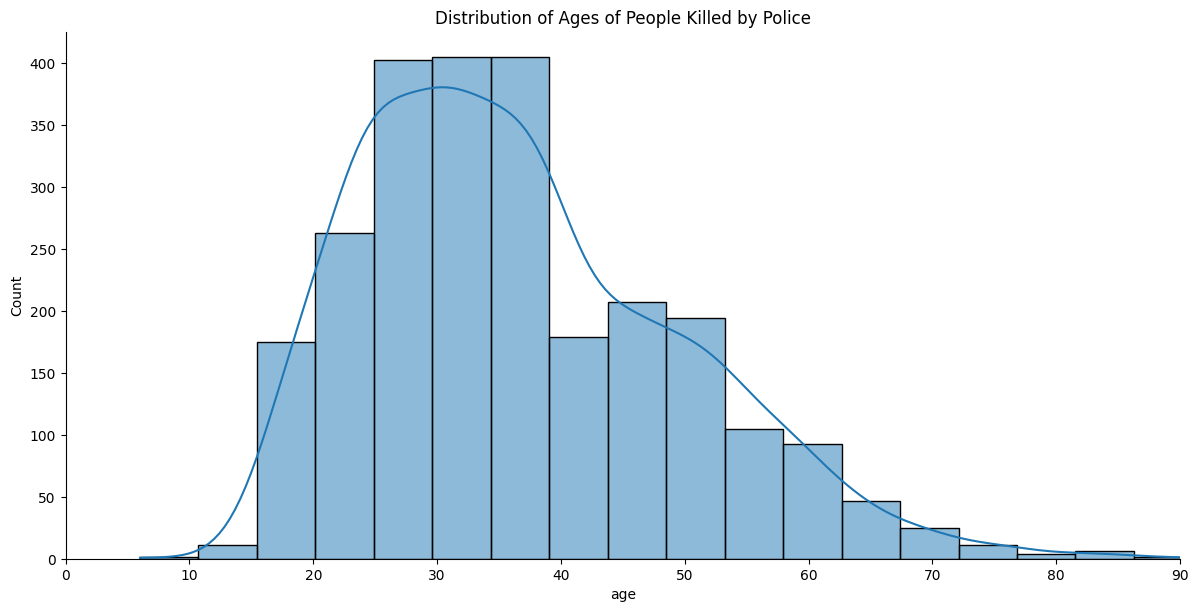

In [221]:
#plot histogram showing age distribution of people killed
sns_displot = sns.displot(df_fatalities,
                        x='age',
                        bins=18,
                        kde=True,
                        height=6,
                        aspect=2)
plt.title('Distribution of Ages of People Killed by Police', loc='center')
plt.xlim(0,90)
plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions?

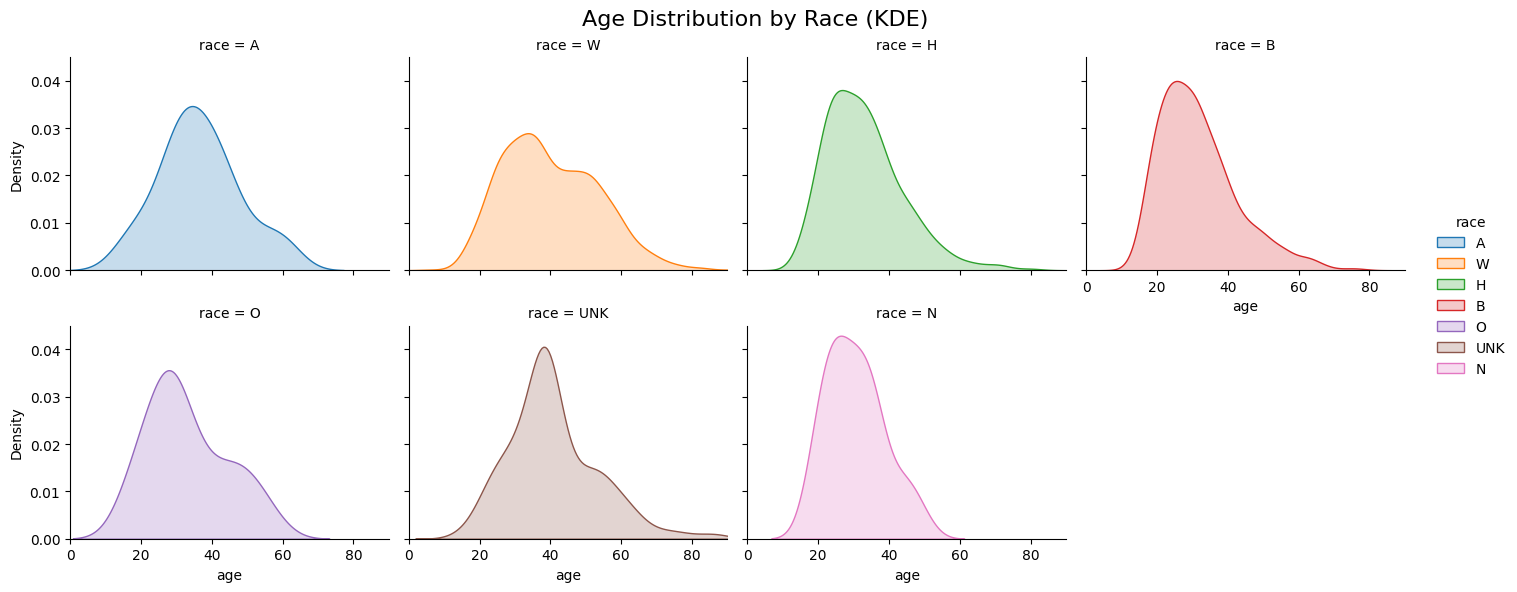

In [222]:
#create separate KDE plots for each race
sns.displot(df_fatalities,
            x='age',
            kind='kde',
            col='race',
            col_wrap=4,
            height=3,
            aspect=1.2,
            hue='race',
            fill=True,
            common_norm=False,
            facet_kws={'sharey': True})# normalize y-axis across facets

plt.xlim(0, 90)
plt.subplots_adjust(top=0.9)
plt.suptitle('Age Distribution by Race (KDE)', fontsize=16)
plt.show()


# Race of People Killed

Create a chart that shows the total number of people killed by race.

In [223]:
from matplotlib import legend

#get the count of people killed by race
killed_race = df_fatalities['race'].value_counts().reset_index()

#plot bar chart
bar = px.bar(killed_race,
             x='race',
             y='count',
             title='Total Number of People Killed by Race',
             color='race',
             )

bar.update_layout(xaxis_title='Race', yaxis_title='Count', showlegend=False)

bar.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [224]:
#filter to include only people with mental illness and get sum
mental_illness = df_fatalities['signs_of_mental_illness']==True
sum_mental_illness = mental_illness.sum()

#calculate percent of people killed that had a mental illness
pct_mental_illness = (sum_mental_illness/total_killed) * 100
print(f"{pct_mental_illness: .2f}% of people killed by the police were mentally ill")


 24.97% of people killed by the police were mentally ill


# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [225]:
#group data by city and count the size, then sort in descendign or by size
city_killed = df_fatalities.groupby('city', as_index=False).size().sort_values(by='size', ascending=False)
city_killed

,city,size
732,Los Angeles,39
995,Phoenix,31
578,Houston,27
241,Chicago,25
687,Las Vegas,21
...,...,...
1392,Wink,1
1393,Winnie,1
1394,Winnsboro,1
1395,Winooski,1


In [226]:
#plot bar chart
h_bar = px.bar(city_killed[:10],
               x='size',
               y='city',
               title='Top 10 Cities with the Most Police Killings',
               color='city',
               orientation='h',
               height=700)

h_bar.update_layout(xaxis_title='Count', yaxis_title='City', showlegend=False)
h_bar.update_layout(
    title_font=dict(size=22),
    xaxis_title_font=dict(size=16),
    yaxis_title_font=dict(size=16),
    xaxis=dict(tickfont=dict(size=12)),
    yaxis=dict(tickfont=dict(size=12))
)

h_bar.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city.

In [270]:
#Identify the top 10 cities
top_10_cities = df_fatalities['city'].value_counts().nlargest(10)
city_order = top_10_cities.index.tolist()

#filter dataframe to include only top 10 cities
df_top_10_cities = df_fatalities[df_fatalities['city'].isin(city_order)]

#group by city and race to count fatalities
race_counts = df_top_10_cities.groupby(['city', 'race']).size().reset_index(name='count')

#calculate total fatalities by city
total_counts = race_counts.groupby('city')['count'].transform('sum')
race_counts['share'] = race_counts['count'] / total_counts

#apply categorical ordering
race_counts['city'] = pd.Categorical(race_counts['city'], categories=city_order, ordered=True)
race_counts = race_counts.sort_values('city')

race_counts

,city,race,count,share
24,Los Angeles,UNK,3,0.08
23,Los Angeles,H,19,0.49
22,Los Angeles,B,10,0.26
25,Los Angeles,W,6,0.15
21,Los Angeles,A,1,0.03
31,Phoenix,H,11,0.35
30,Phoenix,B,2,0.06
32,Phoenix,N,3,0.10
34,Phoenix,W,12,0.39
33,Phoenix,UNK,3,0.10


In [308]:
#plot stacked bar graph

sbar = px.bar(race_counts,
              x='city',
              y='share',
              color='race',
              title='Racial Share of Fatalities in Top 10 Cities',
              barmode='stack',
              height=700)

sbar.update_layout(xaxis_title='City', yaxis_title='Share of Fatalities')


sbar.show()

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty?

In [280]:
#group data by state and get count
fatal_by_state = df_fatalities.groupby('state').size().reset_index(name='fatalities')
fatal_by_state

,state,fatalities
0,AK,15
1,AL,50
2,AR,26
3,AZ,118
4,CA,424
5,CO,74
6,CT,9
7,DC,11
8,DE,8
9,FL,154


In [361]:
#create Choropleth map
c_map = px.choropleth(fatal_by_state,
                      locations='state',
                      locationmode='USA-states',
                      scope='usa',
                      color='fatalities',
                      color_continuous_scale='reds',
                      title='Police Killings By US State')

c_map.update_layout(geo=dict(bgcolor='rgba(0,0,0,0)'),  # Transparent background
                    margin=dict(l=0, r=0, t=50, b=0))

c_map.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data?

In [295]:
#convert date to datetime
df_fatalities['date'] = pd.to_datetime(df_fatalities['date'], errors='coerce')
df_fatalities.head()

,id,name,date,manner_of_death,armed,age,gender,race,city,state,signs_of_mental_illness,threat_level,flee,body_camera,age_missing
0,3,Tim Elliot,2015-02-01,shot,gun,53.00,M,A,Shelton,WA,True,attack,Not fleeing,False,False
1,4,Lewis Lee Lembke,2015-02-01,shot,gun,47.00,M,W,Aloha,OR,False,attack,Not fleeing,False,False
2,5,John Paul Quintero,2015-03-01,shot and Tasered,unarmed,23.00,M,H,Wichita,KS,False,other,Not fleeing,False,False
3,8,Matthew Hoffman,2015-04-01,shot,toy weapon,32.00,M,W,San Francisco,CA,True,attack,Not fleeing,False,False
4,9,Michael Rodriguez,2015-04-01,shot,nail gun,39.00,M,H,Evans,CO,False,attack,Not fleeing,False,False


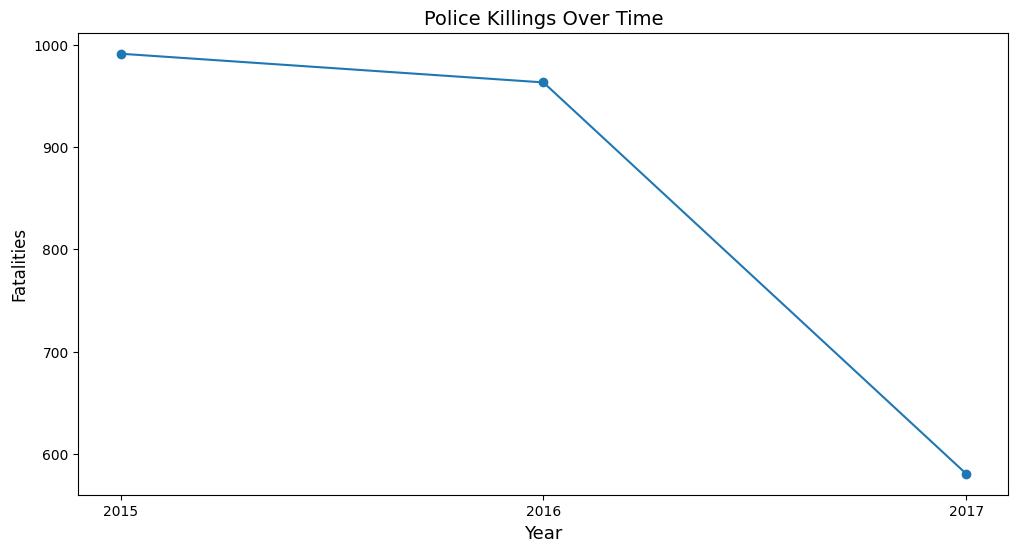

In [338]:
#analyze by yearly timeframe
df_yearly = df_fatalities['date'].dt.year.value_counts().sort_index()
df_yearly = df_yearly.reset_index()
df_yearly.columns = ['year', 'fatalities']
df_yearly['year'] = df_yearly['year'].astype(str)


#plot yearly timeframe
plt.figure(figsize=(12,6))

plt.plot(df_yearly.year, df_yearly.fatalities, marker='o')

plt.title('Police Killings Over Time', fontsize=14)
plt.xlabel('Year', fontsize=13)
plt.ylabel('Fatalities', fontsize=12)

plt.show()

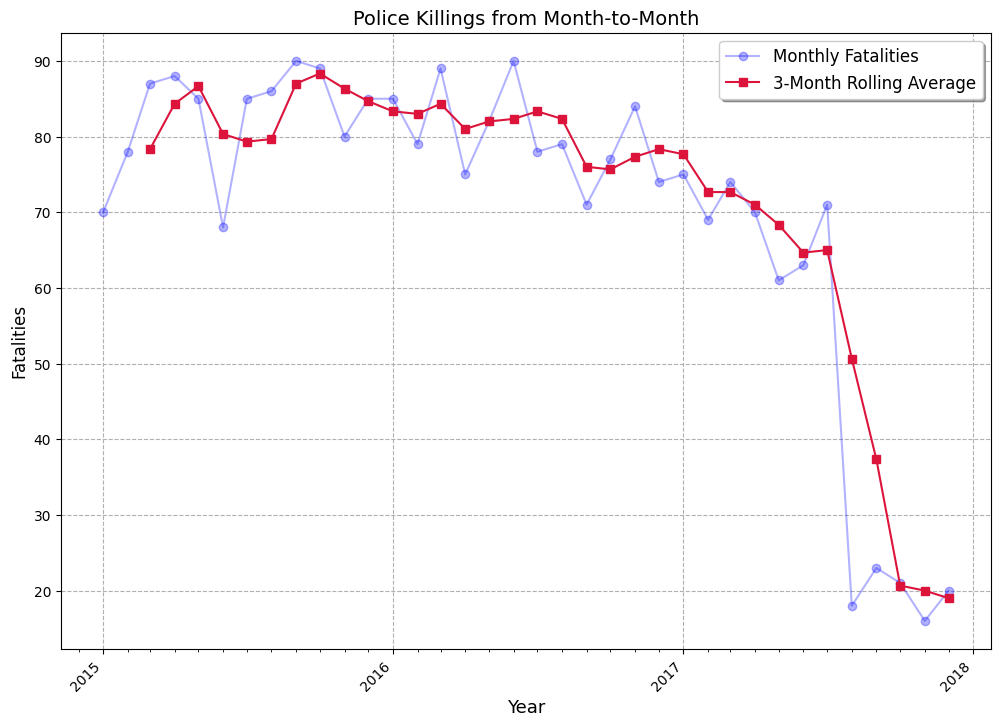

In [360]:
import matplotlib.dates as mdates

#analyze monthly timeframe
df_monthly = df_fatalities['date'].dt.to_period('M').value_counts().sort_index()
df_monthly = df_monthly.reset_index()
df_monthly.columns = ['month', 'fatalities']
df_monthly['month'] = df_monthly['month'].dt.to_timestamp()

#use rolling average to smooth monthly data
df_monthly['rolling_avg'] = df_monthly['fatalities'].rolling(window=3).mean()

#plot monthly timeframe
plt.figure(figsize=(12,8))

plt.plot(df_monthly.month, df_monthly.fatalities, marker='o', color='blue', label='Monthly Fatalities', alpha=0.3)
plt.plot(df_monthly.month, df_monthly.rolling_avg, marker='s', color='crimson', label='3-Month Rolling Average')

plt.legend(fontsize=12, frameon=True, shadow=True)
plt.title('Police Killings from Month-to-Month', fontsize=14)
plt.xlabel('Year', fontsize=13)
plt.ylabel('Fatalities', fontsize=12)
plt.grid(linestyle='--')

#create locators for ticks on the time axis
years = mdates.YearLocator()
months = mdates.MonthLocator()
years_fmt = mdates.DateFormatter('%Y')

#format the ticks on the xaxis
#get current xaxis
ax = plt.gca()

#major ticks every year
ax.xaxis.set_major_locator(years)
ax.xaxis.set_major_formatter(years_fmt)
# minor ticks every month
ax.xaxis.set_minor_locator(months)

# rotate labels for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.show()

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).